In [2]:
import os
# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "wasifmostofa36"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
   print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
   print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

today_dir = "Assignments/HW4"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/wasifmostofa36/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/wasifmostofa36/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/HW4


# STAT 7220 - Homework 4
## Mixed Effects Experiments
## Dr. Austin Brown
## Due Date: April 24, 2026

## Instructions:

The International Paralympic Committee is evaluating two new carbon-fiber blade designs: Model A (Aerostep) and Model B (Bionic-Flex). The goal is to determine if either new design yields meaningfully different 100-meter sprint times among T64 sprinters. Note, a T64 sprinter is an athlete with an absence of one leg below the knee.

Because sprint performance is highly dependent on an individual athlete’s biomechanics, muscle composition, and training level, the research team has recruited 5 professional T64 sprinters to participate in a study. Each athlete will perform three timed trials with both of the blade types in a randomized order. In this experiment, we want to control for the variability of individual athletes, but we are most interested in comparing the mean differences between the two blade designs. The results of this experiment are contained in the `Paralympic_Blade_Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.


* The goal is to analyze the mean differences between the two new carbon fiber blade designs (ie Model A (Aerostep) and Model B (Bionic-Flex)) while controlling for the variability of the individual athletes.

2.  Specify the outcome variable and how it is measured.


* The outcome variable is the 100 meter sprint times among the 5 professional T64 sprinters participating in the study.

3.  Specify the independent variables, including which is fixed and which is random. What lurking variables may be present?

* Here, we are interested in comparing the mean sprint time scores across different, specific blade designs (fixed effect) while controlling for the variability introduced by different, random athletes (random effect)
* Since we are working with humans, lurking variables will be present
  * personal bias of the material among athletes
  * speed performance of the athletes prior to the experiment
  * health of the athlete on the day of the experiment

4.  Explain the difference between a random effect and a fixed effect. Why should we account for random effects in our designs?

* A fixed effect is when Data has been gathered from all the levels of the factor that are of interest. Essentially, we are interested in comparing the means of the response variable across the specific levels of the categorical factors.
* A random effect is a categorical factor whose specific value is not necessarily of interest to the experimenter. The factor has many possible levels, interest is in all possible levels, but only a random sample of levels is included in the data.

5.  State the sets of null and alternative hypotheses for this experiment.

$$ H_{null}: \alpha_{\text{Mean sprinter time scores for model1}} = \alpha_{\text{Mean sprinter time scores for model1}} = 0 $$
$$ H_{Alternative}: \text{At least one } \alpha_i \neq 0 $$

6.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?

  Athlete_ID   Blade_Type  Trial  Sprint_Time
0  Athlete_1     Aerostep      1        11.63
1  Athlete_1     Aerostep      2        11.57
2  Athlete_1     Aerostep      3        11.39
3  Athlete_1  Bionic-Flex      1        11.74
4  Athlete_1  Bionic-Flex      2        11.68
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Athlete_ID   30 non-null     object 
 1   Blade_Type   30 non-null     object 
 2   Trial        30 non-null     int64  
 3   Sprint_Time  30 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 1.1+ KB
None
    Blade_Type Athlete_ID       mean       std
0     Aerostep  Athlete_1  11.530000  0.124900
1     Aerostep  Athlete_2  10.960000  0.034641
2     Aerostep  Athlete_3  11.273333  0.032146
3     Aerostep  Athlete_4  11.316667  0.066583
4     Aerostep  Athlete_5  11.220000  0.065574
5  Bionic-Flex  Athle

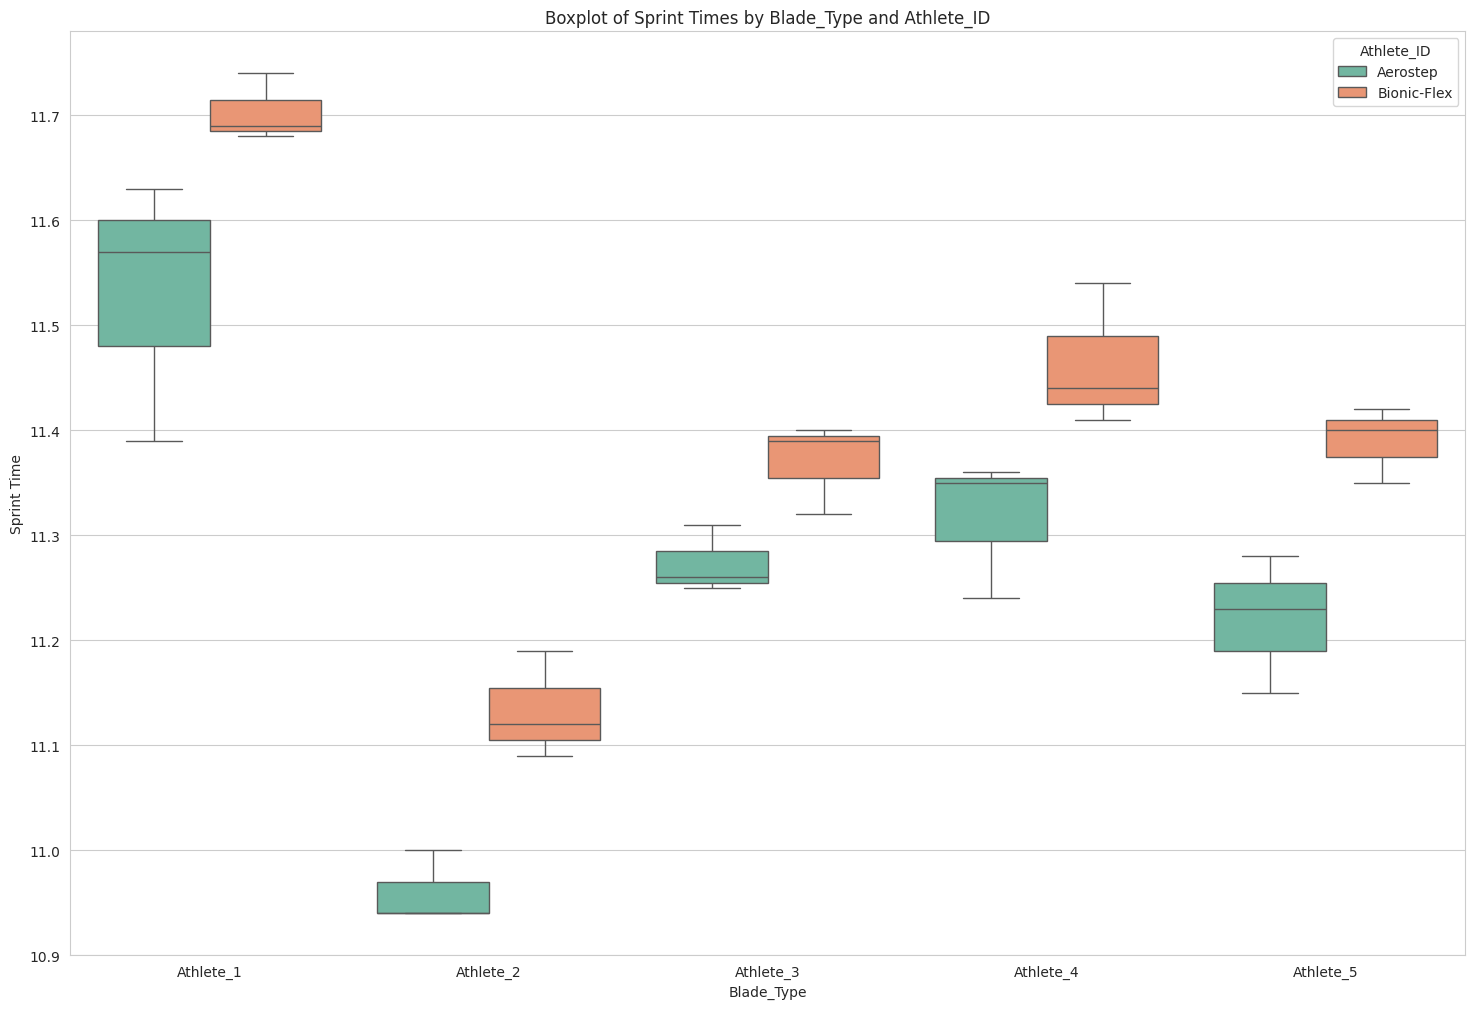

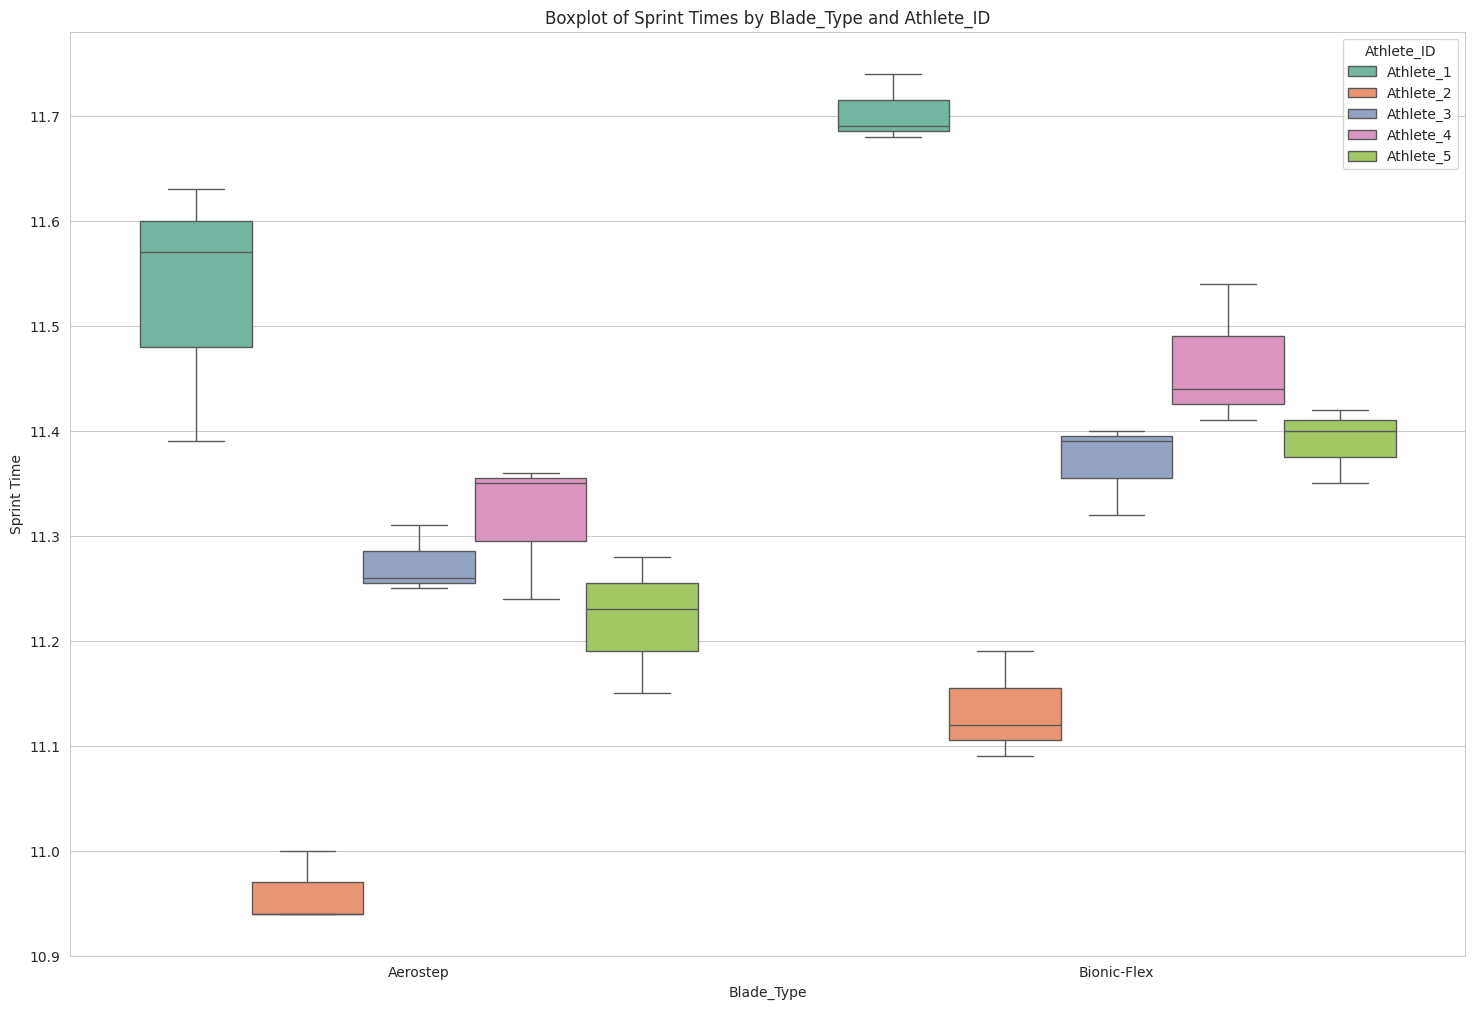

In [9]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
## Import the Data ##

Para = pd.read_excel("STAT Paralympic_Blade_Experiment.xlsx")

## Evaluate Data Integrity ##

print(Para.head())
print(Para.info())

## Run Exploratory Data Analysis ##

## Calculate Means and SDs by School and Teacher ##

BladeType_Athlete_stats = Para.groupby(['Blade_Type', 'Athlete_ID'])['Sprint_Time'].agg(['mean', 'std']).reset_index()
print(BladeType_Athlete_stats)

## Visualize Data using Boxplots ##

sns.set_style("whitegrid") # Use a clean background
plt.figure(figsize=(18, 12))
sns.boxplot(x='Athlete_ID', y='Sprint_Time', hue='Blade_Type', data=Para, palette='Set2')
plt.title('Boxplot of Sprint Times by Blade_Type and Athlete_ID (Per athlete)')
plt.xlabel('Blade_Type')
plt.ylabel('Sprint Time')
plt.legend(title='Athlete_ID')
plt.show()

sns.set_style("whitegrid") # Use a clean background
plt.figure(figsize=(18, 12))
sns.boxplot(x='Blade_Type', y='Sprint_Time', hue='Athlete_ID', data=Para, palette='Set2')
plt.title('Boxplot of Sprint Times by Blade_Type and Athlete_ID (Per bladetype)')
plt.xlabel('Blade_Type')
plt.ylabel('Sprint Time')
plt.legend(title='Athlete_ID')
plt.show()


7. Fit the mixed effects model. Using the model residuals, check the assumption of normality using both a testing method and a visual method. Do we have support for the assumption of normality from the data? Why or why not?

In [ ]:
## Question 7 Code ##

8. **Using the visual method described in the lecture notes**, check the assumption of constant variance. Do we have support for the assumption of constant variance? Why or why not?

In [ ]:
## Question 8 Code ##

9. Report and interpret the result of the random effect. Which of the two hypotheses for the random effect are more strongly supported by the data?

In [ ]:
## Question 9 Code ##

10. Report and interpret the result of the fixed effect. Which of the two hypotheses for the fixed effect are more strongly supported by the data?

In [ ]:
## Question 10 Code ##

11. Finally, provide a brief contextual conclusion for this experiment. Discuss experiment limitations and future directions.